In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
#pip install scikit-learn

In [2]:
# %%
np.random.seed(42)

genders = ["male", "female"]
race_groups = ["group A", "group B", "group C", "group D", "group E"]

parent_education = [
    "some high school", "high school", "some college",
    "associate's degree", "bachelor's degree", "master's degree"
]

lunch_types = ["standard", "free/reduced"]
test_prep = ["Incompleted", "completed"]

n = 20

data = {
    "gender": np.random.choice(genders, n),
    "race/ethnicity": np.random.choice(race_groups, n),
    "parental level of education": np.random.choice(parent_education, n),
    "lunch": np.random.choice(lunch_types, n),
    "test preparation course": np.random.choice(test_prep, n),
    "math score": np.random.randint(40, 100, n).astype(float),
    "reading score": np.random.randint(40, 100, n).astype(float),
    "writing score": np.random.randint(40, 100, n).astype(float)
}

df = pd.DataFrame(data)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,79.0,46.0,67.0
1,female,group B,some high school,free/reduced,Incompleted,60.0,48.0,46.0
2,male,group D,some college,standard,Incompleted,55.0,63.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,84.0,40.0,47.0
4,male,group D,some college,standard,completed,57.0,83.0,51.0


In [ ]:
# %%
numeric_cols = ["math score", "reading score", "writing score"]

# Inject outliers
df.loc[0, 'math score'] = 10
df.loc[1, 'math score'] = 5
df.loc[2, 'math score'] = 0   # handled later safely
df.loc[3, 'math score'] = 160
df.loc[4, 'math score'] = 180

# Inject missing values
for col in numeric_cols:
    df.loc[df.sample(frac=0.1).index, col] = np.nan #frac=0.1 means select 10% random rows

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,10.0,46.0,67.0
1,female,group B,some high school,free/reduced,Incompleted,5.0,48.0,46.0
2,male,group D,some college,standard,Incompleted,0.0,63.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,160.0,40.0,47.0
4,male,group D,some college,standard,completed,180.0,83.0,NaN
5,female,group E,bachelor's degree,free/reduced,completed,86.0,47.0,73.0
6,male,group A,some high school,standard,completed,92.0,63.0,72.0
7,male,group D,high school,standard,completed,63.0,50.0,87.0
8,male,group B,associate's degree,free/reduced,completed,65.0,90.0,94.0
9,female,group E,some high school,standard,completed,64.0,56.0,NaN


In [4]:
# %%
print("Dataset Info:")
display(df.describe())

print("\nShape:", df.shape)

print("\nMissing Values:\n", df.isnull().sum())

Dataset Info:


,math score,reading score,writing score
count,18.000000,18.000000,18.000000
mean,76.222222,65.500000,68.000000
std,46.141159,19.321582,14.919391
min,0.000000,40.000000,40.000000
25%,63.250000,47.250000,61.500000
50%,74.000000,63.000000,72.500000
75%,97.250000,80.750000,75.500000
max,180.000000,98.000000,94.000000



Shape: (20, 8)

Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     2
reading score                  2
writing score                  2
dtype: int64


In [5]:
# %%
# Fill missing values with mean
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("After Filling Missing Values:\n", df.isnull().sum())

df.head()

After Filling Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,10.0,46.0,67.0
1,female,group B,some high school,free/reduced,Incompleted,5.0,48.0,46.0
2,male,group D,some college,standard,Incompleted,0.0,63.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,160.0,40.0,47.0
4,male,group D,some college,standard,completed,180.0,83.0,68.0


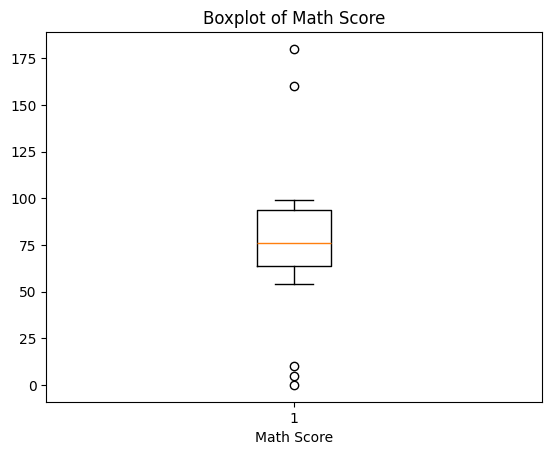

In [6]:
# %%
# Boxplot
plt.figure()
plt.boxplot(df['math score'])
plt.title("Boxplot of Math Score")
plt.xlabel("Math Score")
plt.show()

In [7]:
# %%
# IQR method for outliers
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[(df['math score'] < lower_limit) | (df['math score'] > upper_limit)]
outliers

Q1: 63.75
Q3: 93.75
IQR: 30.0
Lower Limit: 18.75
Upper Limit: 138.75


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,10.0,46.0,67.0
1,female,group B,some high school,free/reduced,Incompleted,5.0,48.0,46.0
2,male,group D,some college,standard,Incompleted,0.0,63.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,160.0,40.0,47.0
4,male,group D,some college,standard,completed,180.0,83.0,68.0


In [8]:
# %%
# Remove outliers + FIX (copy issue)
df_clean = df[(df['math score'] >= lower_limit) & (df['math score'] <= upper_limit)]
df_clean = df_clean.copy()

print("Shape after removing outliers:", df_clean.shape)

Shape after removing outliers: (15, 8)


In [9]:
# %%
# Scaling + transformations
scaler = MinMaxScaler()

df_clean['math_scaled'] = scaler.fit_transform(df_clean[['math score']])

# Z-score normalization
df_clean['math_zscore'] = (
    df_clean['math score'] - df_clean['math score'].mean()
) / df_clean['math score'].std()

# FIX: avoid log(0)
df_clean['math_log'] = np.log(df_clean['math score'] + 1)

df_clean.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,math_scaled,math_zscore,math_log
5,female,group E,bachelor's degree,free/reduced,completed,86.0,47.0,73.0,0.711111,0.540866,4.465908
6,male,group A,some high school,standard,completed,92.0,63.0,72.0,0.844444,0.944645,4.532599
7,male,group D,high school,standard,completed,63.0,50.0,87.0,0.200000,-1.006957,4.158883
8,male,group B,associate's degree,free/reduced,completed,65.0,90.0,94.0,0.244444,-0.872364,4.189655
9,female,group E,some high school,standard,completed,64.0,56.0,68.0,0.222222,-0.939661,4.174387


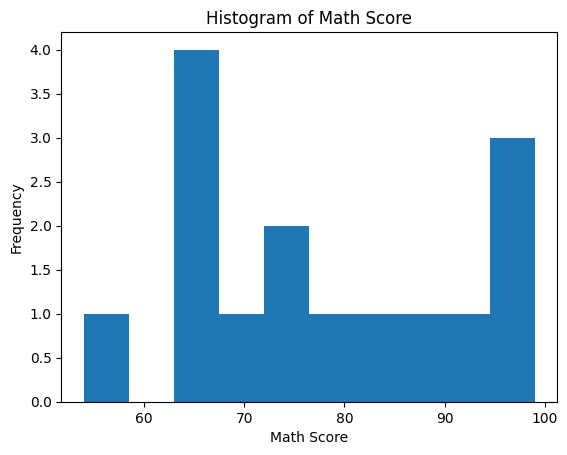

In [10]:
# %%
# Histogram
plt.figure()
plt.hist(df_clean['math score'], bins=10)
plt.title("Histogram of Math Score")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

In [11]:
# %%
print("Final Statistical Summary:\n")
display(df_clean.describe())

Final Statistical Summary:



,math score,reading score,writing score,math_scaled,math_zscore,math_log
count,15.000000,15.000000,15.000000,15.000000,1.500000e+01,15.000000
mean,77.962963,68.666667,72.266667,0.532510,9.621933e-17,4.352216
std,14.859582,18.021482,12.492665,0.330213,1.000000e+00,0.190373
min,54.000000,44.000000,40.000000,0.000000,-1.612627e+00,4.007333
25%,64.500000,53.000000,67.000000,0.233333,-9.060122e-01,4.182021
50%,76.222222,65.500000,74.000000,0.493827,-1.171460e-01,4.346687
75%,89.000000,80.500000,77.500000,0.777778,7.427556e-01,4.499254
max,99.000000,98.000000,94.000000,1.000000,1.415722e+00,4.605170
